In [1]:
import torch
import pandas
import torchvision
import os
from torch.utils.data import Dataset,DataLoader
import scipy.io as scio
# Hyper parameters
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F  # 添加这一行引入torch.nn.functional模块
import copy
import numpy as np
import matplotlib
import time
import h5py
from matplotlib import animation
from sklearn.metrics import confusion_matrix
from matplotlib.animation import FuncAnimation
from matplotlib import pyplot as plt
import hiddenlayer as hl
import pywt
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
class MyDataset(Dataset):
    def __init__(self,root,sets):
       f = h5py.File(root ,'r')
       if sets == 'train':
           self.X = f['X_train'][:]
           self.y = f['y_train'][:]
       elif sets == 'val':
           self.X = f['X_val'][:]
           self.y = f['y_val'][:]
       else:
           self.X = f['X_test'][:]
           self.y = f['y_test'][:] 
    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [3]:
#小波降噪模块
class WaveletDenoising(nn.Module):
    def __init__(self, wavelet='db4', level=3, threshold_factor=1.0, learnable_threshold=True):
        """
        小波降噪层
        参数:
            wavelet: 使用的小波基，默认'db4'
            level: 分解层数，默认3
            threshold_factor: 初始阈值因子，默认1.0
            learnable_threshold: 是否让阈值可学习，默认True
        """
        super(WaveletDenoising, self).__init__()
        self.wavelet = wavelet
        self.level = level
        self.threshold_factor = nn.Parameter(torch.tensor(threshold_factor), requires_grad=learnable_threshold)
        self.learnable_threshold = learnable_threshold
        
    def forward(self, x):
        # 确保在CPU上执行小波变换（PyTorch目前没有GPU小波变换）
        device = x.device
        x_np = x.cpu().detach().numpy()
        
        # 处理批处理维度
        batch_size, channels, height, width = x_np.shape
        denoised_signals = np.zeros_like(x_np)
        
        # 对批次中的每个样本进行小波降噪
        for b in range(batch_size):
            for c in range(channels):
                # 提取单个信号 (1, height, 1) -> (height,)
                signal = x_np[b, c, :, 0].squeeze()
                
                # 小波分解
                coeffs = pywt.wavedec(signal, self.wavelet, level=self.level)
                
                # 计算阈值
                sigma = np.median(np.abs(coeffs[-1])) / 0.6745  # 噪声估计
                threshold = self.threshold_factor.item() * sigma * np.sqrt(2 * np.log(len(signal)))
                
                # 应用软阈值
                thresholded_coeffs = [coeffs[0]]  # 近似系数保持不变
                for i in range(1, len(coeffs)):
                    thresholded_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='soft'))
                
                # 小波重构
                denoised_signal = pywt.waverec(thresholded_coeffs, self.wavelet)
                
                # 确保长度匹配
                if len(denoised_signal) > height:
                    denoised_signal = denoised_signal[:height]
                elif len(denoised_signal) < height:
                    denoised_signal = np.pad(denoised_signal, (0, height - len(denoised_signal)), 'constant')
                
                # 存储结果
                denoised_signals[b, c, :, 0] = denoised_signal
        
        # 返回PyTorch张量
        return torch.tensor(denoised_signals, dtype=x.dtype).to(device)

In [4]:
Epoch = 300
Batch_Size = 200
Learning_Rate = 0.001

In [5]:
data_path = 'CWRU_test_noisy_SNR10.h5'
train_dataset = MyDataset(data_path, 'train')
val_dataset = MyDataset(data_path, 'val')

# 查看训练集的结构
for i in range(len(train_dataset)):
    input_data, label_data = train_dataset[i]
    print("Train Sample ", i)
    print("Input Shape:", input_data.shape)
    print("Label Shape:", label_data.shape)
    # 可以根据实际情况打印更多信息

# 查看验证集的结构
for i in range(len(val_dataset)):
    input_data, label_data = val_dataset[i]
    print("Validation Sample ", i)
    print("Input Shape:", input_data.shape)
    print("Label Shape:", label_data.shape)
    # 可以根据实际情况打印更多信息
    
    
train_loader = DataLoader(train_dataset, batch_size=Batch_Size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Batch_Size, shuffle=True)
# Checking the dataset
for dataset, labels in train_loader:
    print('Signals batch dimensions:', dataset.shape)#四维张量可以被理解为包含200个样本，每个样本有1个通道，
                                                     #每个通道包含1024个元素，每个元素的深度为1
    print('Signals label dimensions:', labels.shape)
    break
print('#training num = %d' % len(train_dataset))
print('#val num = %d' % len(val_dataset))

Train Sample  0
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  1
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  2
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  3
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  4
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  5
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  6
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  7
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  8
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  9
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  10
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  11
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  12
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  13
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  14
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  15
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  16
Input Shape: (1, 1024, 1)
Label Shape: ()
Train S

In [6]:
#在上面的代码中，我们在您提供的CNN-LSTM模型中增加了一个MultiheadAttention层作为注意力机制。在forward方法中，
#我们首先通过CNN和LSTM层处理输入数据，然后引入注意力机制，最后通过全连接层输出最终的分类结果。
class CNN_LSTM_Attention(nn.Module):
    def __init__(self):
        super(CNN_LSTM_Attention, self).__init__()
        
        # 添加小波降噪层
        self.wavelet_denoise = WaveletDenoising(
            wavelet='db4', 
            level=3,
            threshold_factor=1.0,
            learnable_threshold=True
        )
        #原有CNN结构
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=[16, 1], stride=[7, 1], padding=0, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=[7, 1], stride=[4, 1], padding=0, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=[3, 1], stride=[2, 1], padding=0, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.lstm = nn.LSTM(input_size=17, hidden_size=64, num_layers=2, bias=False, batch_first=True)
        self.attention = nn.MultiheadAttention(embed_dim=64, num_heads=1)
        self.fully_connect = nn.Linear(64, 11)  # 11 types classification
        self.classifier = nn.Softmax(dim=1)

    def forward(self, x):
        
        # 首先通过小波降噪层
        x = self.wavelet_denoise(x)

        residual = x  # 保存输入作为残差连接的输入
        x = self.cnn(x)
        
        # 处理残差连接的输入维度
        residual = F.interpolate(residual, size=x.size()[2:], mode='nearest')
        
        x = x + residual  # 添加残差连接
        
        y, _ = self.lstm(x.squeeze(3))
        
        # 注意力机制
        attention_output, _ = self.attention(y, y, y)
        
        logits = self.fully_connect(attention_output[:, -1, :])
        probs = self.classifier(logits)
        return logits, probs

In [7]:
# 实例化模型
model = CNN_LSTM_Attention()

In [8]:
# 定义优化器和损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=Learning_Rate)
loss_func = nn.CrossEntropyLoss()

epoch 0
Training Accuracy is  0.135
Training Accuracy is  0.115
Training Accuracy is  0.070
Training Accuracy is  0.080
Training Accuracy is  0.035
Training Accuracy is  0.090
Training Accuracy is  0.100
Training Accuracy is  0.105
Training Accuracy is  0.105
Training Accuracy is  0.070
Training Accuracy is  0.095
epoch 1
Training Accuracy is  0.120
Training Accuracy is  0.090
Training Accuracy is  0.100
Training Accuracy is  0.105
Training Accuracy is  0.080
Training Accuracy is  0.065
Training Accuracy is  0.120
Training Accuracy is  0.105
Training Accuracy is  0.070
Validation Accuracy is  0.115
Validation Accuracy is  0.085
Validation Accuracy is  0.125
Validation Accuracy is  0.045
Validation Accuracy is  0.100
Validation Accuracy is  0.085
Validation Accuracy is  0.085
Validation Accuracy is  0.130
Validation Accuracy is  0.055
Validation Accuracy is  0.075
Validation Accuracy is  0.100
Training Accuracy is  0.085
Training Accuracy is  0.060
epoch 2
Training Accuracy is  0.090
Tr

Training Accuracy is  0.185
Training Accuracy is  0.255
Training Accuracy is  0.195
Training Accuracy is  0.210
Training Accuracy is  0.205
epoch 17
Training Accuracy is  0.230
Training Accuracy is  0.225
Training Accuracy is  0.205
Training Accuracy is  0.175
Training Accuracy is  0.290
Training Accuracy is  0.250
Training Accuracy is  0.240
Training Accuracy is  0.240
Training Accuracy is  0.275
Training Accuracy is  0.235
Training Accuracy is  0.230
epoch 18
Training Accuracy is  0.230
Training Accuracy is  0.225
Validation Accuracy is  0.205
Validation Accuracy is  0.195
Validation Accuracy is  0.260
Validation Accuracy is  0.180
Validation Accuracy is  0.285
Validation Accuracy is  0.190
Validation Accuracy is  0.185
Validation Accuracy is  0.200
Validation Accuracy is  0.210
Validation Accuracy is  0.185
Validation Accuracy is  0.195
Training Accuracy is  0.215
Training Accuracy is  0.260
Training Accuracy is  0.215
Training Accuracy is  0.230
Training Accuracy is  0.230
Training

Training Accuracy is  0.415
Training Accuracy is  0.540
Training Accuracy is  0.590
Training Accuracy is  0.625
Training Accuracy is  0.565
Training Accuracy is  0.480
Training Accuracy is  0.605
Training Accuracy is  0.555
Training Accuracy is  0.515
Training Accuracy is  0.580
epoch 34
Training Accuracy is  0.480
Training Accuracy is  0.495
Training Accuracy is  0.565
Training Accuracy is  0.470
Training Accuracy is  0.465
Training Accuracy is  0.360
Validation Accuracy is  0.565
Validation Accuracy is  0.470
Validation Accuracy is  0.360
Validation Accuracy is  0.570
Validation Accuracy is  0.590
Validation Accuracy is  0.485
Validation Accuracy is  0.490
Validation Accuracy is  0.405
Validation Accuracy is  0.470
Validation Accuracy is  0.420
Validation Accuracy is  0.465
Training Accuracy is  0.385
Training Accuracy is  0.375
Training Accuracy is  0.560
Training Accuracy is  0.485
Training Accuracy is  0.540
epoch 35
Training Accuracy is  0.565
Training Accuracy is  0.505
Training

Training Accuracy is  0.610
Training Accuracy is  0.345
Training Accuracy is  0.745
Training Accuracy is  0.640
epoch 50
Training Accuracy is  0.605
Training Accuracy is  0.325
Training Accuracy is  0.670
Training Accuracy is  0.755
Training Accuracy is  0.720
Training Accuracy is  0.580
Training Accuracy is  0.505
Training Accuracy is  0.705
Training Accuracy is  0.390
Training Accuracy is  0.625
Validation Accuracy is  0.240
Validation Accuracy is  0.265
Validation Accuracy is  0.405
Validation Accuracy is  0.295
Validation Accuracy is  0.230
Validation Accuracy is  0.580
Validation Accuracy is  0.485
Validation Accuracy is  0.490
Validation Accuracy is  0.360
Validation Accuracy is  0.340
Validation Accuracy is  0.285
Training Accuracy is  0.430
epoch 51
Training Accuracy is  0.535
Training Accuracy is  0.530
Training Accuracy is  0.690
Training Accuracy is  0.785
Training Accuracy is  0.665
Training Accuracy is  0.485
Training Accuracy is  0.655
Training Accuracy is  0.615
Training

Training Accuracy is  0.910
Training Accuracy is  0.870
Training Accuracy is  0.930
Training Accuracy is  0.845
Training Accuracy is  0.895
Training Accuracy is  0.845
Training Accuracy is  0.830
Training Accuracy is  0.960
Training Accuracy is  0.900
epoch 67
Training Accuracy is  0.920
Training Accuracy is  0.935
Training Accuracy is  0.960
Validation Accuracy is  0.490
Validation Accuracy is  0.855
Validation Accuracy is  0.480
Validation Accuracy is  0.810
Validation Accuracy is  0.760
Validation Accuracy is  0.775
Validation Accuracy is  0.605
Validation Accuracy is  0.645
Validation Accuracy is  0.615
Validation Accuracy is  0.800
Validation Accuracy is  0.670
Training Accuracy is  0.690
Training Accuracy is  0.865
Training Accuracy is  0.735
Training Accuracy is  0.970
Training Accuracy is  0.970
Training Accuracy is  0.940
Training Accuracy is  0.795
Training Accuracy is  0.965
epoch 68
Training Accuracy is  0.865
Training Accuracy is  0.910
Training Accuracy is  0.925
Training

...

Validation Accuracy is  0.935
Validation Accuracy is  0.985
Validation Accuracy is  0.980
Validation Accuracy is  0.980
Validation Accuracy is  0.985
Validation Accuracy is  0.985
Validation Accuracy is  0.775
Validation Accuracy is  0.990
Validation Accuracy is  0.765
Validation Accuracy is  0.985
Validation Accuracy is  0.885
Training Accuracy is  1.000
epoch 231
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
epoch 232
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Validation Accuracy is  0.975
Validation Accuracy is  0.985
Validation Accuracy is  0.980


Validation Accuracy is  0.970
Validation Accuracy is  0.830
Validation Accuracy is  0.780
Validation Accuracy is  0.970
Validation Accuracy is  0.990
Validation Accuracy is  0.910
Validation Accuracy is  0.980
Validation Accuracy is  0.995
Validation Accuracy is  0.740
Validation Accuracy is  0.990
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
epoch 248
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  0.995
Training Accuracy is  1.000
epoch 249
Training Accuracy is  1.000
Validation Accuracy is  0.870
Validation Accuracy is  0.995
Validation Accuracy is  0.845
Validation Accuracy is  0.960


Validation Accuracy is  0.760
Validation Accuracy is  0.935
Validation Accuracy is  0.985
Validation Accuracy is  0.955
Validation Accuracy is  0.800
Validation Accuracy is  0.960
Validation Accuracy is  0.990
Validation Accuracy is  0.950
Validation Accuracy is  0.975
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  0.960
Training Accuracy is  1.000
epoch 264
Training Accuracy is  1.000
Training Accuracy is  0.980
Training Accuracy is  1.000
Training Accuracy is  0.900
Training Accuracy is  1.000
Training Accuracy is  0.975
Training Accuracy is  0.835
Training Accuracy is  1.000
Training Accuracy is  0.955
Training Accuracy is  0.955
Training Accuracy is  0.925
epoch 265
Training Accuracy is  0.990
Training Accuracy is  0.990
Training Accuracy is  0.965
Training Accuracy is  0.970
Training Accuracy is  0.845
Validation Accuracy is  0.980
Validation Accuracy is  0.880
Validation Accuracy is  0.945
Validation Accuracy is  0.950
Validation Accuracy is  0.960


Validation Accuracy is  0.925
Validation Accuracy is  0.945
Validation Accuracy is  0.900
Validation Accuracy is  0.950
Validation Accuracy is  0.945
Validation Accuracy is  0.955
Validation Accuracy is  0.955
Validation Accuracy is  0.960
epoch 280
Training Accuracy is  0.995
Training Accuracy is  0.910
Training Accuracy is  0.960
Training Accuracy is  0.990
Training Accuracy is  0.955
Training Accuracy is  1.000
Training Accuracy is  0.940
Training Accuracy is  0.955
Training Accuracy is  0.970
Training Accuracy is  0.925
Training Accuracy is  0.925
epoch 281
Training Accuracy is  0.970
Training Accuracy is  0.975
Training Accuracy is  0.920
Training Accuracy is  0.985
Training Accuracy is  0.990
Training Accuracy is  0.905
Training Accuracy is  0.850
Training Accuracy is  0.945
Training Accuracy is  0.970
Validation Accuracy is  0.965
Validation Accuracy is  0.970
Validation Accuracy is  0.955
Validation Accuracy is  0.955
Validation Accuracy is  0.970
Validation Accuracy is  0.950


Validation Accuracy is  0.955
Validation Accuracy is  0.975
Validation Accuracy is  0.985
Validation Accuracy is  0.940
Validation Accuracy is  0.985
Validation Accuracy is  0.970
Validation Accuracy is  0.985
Training Accuracy is  0.995
Training Accuracy is  0.995
Training Accuracy is  0.945
Training Accuracy is  1.000
Training Accuracy is  0.950
Training Accuracy is  0.995
Training Accuracy is  1.000
epoch 297
Training Accuracy is  0.965
Training Accuracy is  1.000
Training Accuracy is  0.995
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  0.985
Training Accuracy is  1.000
Training Accuracy is  0.980
Training Accuracy is  1.000
Training Accuracy is  0.995
Training Accuracy is  1.000
epoch 298
Training Accuracy is  1.000
Training Accuracy is  0.945
Validation Accuracy is  0.980
Validation Accuracy is  0.985
Validation Accuracy is  0.955
Validation Accuracy is  0.955
Validation Accuracy is  0.975
Validation Accuracy is  0.960
Validation Accuracy is  0.945


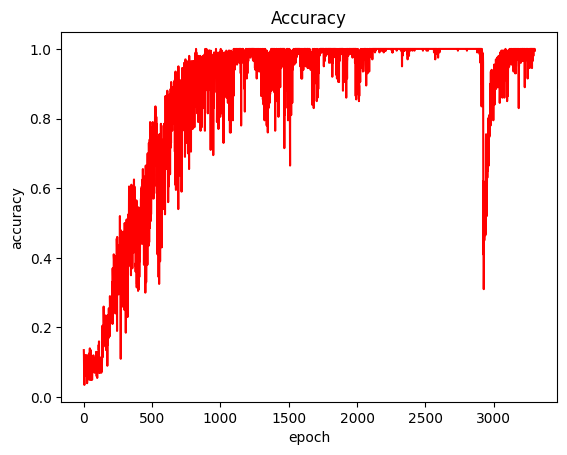

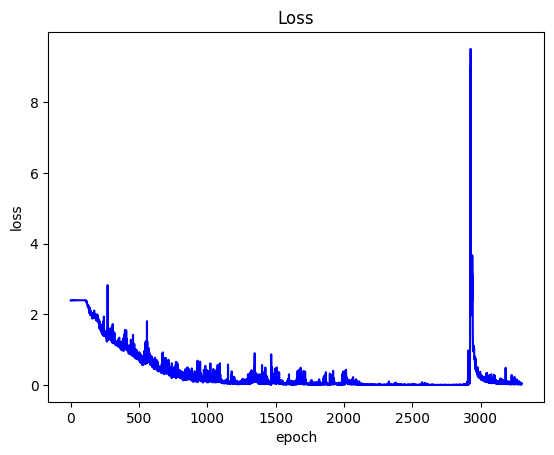

In [9]:
use_cuda = torch.cuda.is_available()
if use_cuda:
    print('CUDA is available')
device = torch.device('cuda:0' if use_cuda else "cpu")
# device = torch.device("cpu")
model = model.to(device)
# save best_model wrt. val_acc
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
Best_Acc = 0.0
loss_list = []
acc_list =[]
val_acc_list = []
val_loss_list = []
global_step = []

history = hl.History()
canvas = hl.Canvas()

for epoch in range(Epoch):
    print ("epoch", epoch)
    for step, (XTrain, YTrain) in enumerate(train_loader):
        num_correct = 0
        model.train()
        XTrain, YTrain = XTrain.float(), YTrain.long()
        XTrain, YTrain = XTrain.to(device), YTrain.to(device)
        logits, probas = model(XTrain)
        loss = loss_func(logits, YTrain)
        preds = probas.max(1, keepdim=True)[1]
        acc = preds.eq(YTrain.view_as(preds)).sum().item() / len(YTrain)
        print("Training Accuracy is %6.3f" % acc)
        loss_list.append(loss)
        acc_list.append(acc)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        global_step.append(epoch * len(train_loader) + step + 1)

        if len(global_step) % 20 == 0:
            model.eval()
            with torch.no_grad():
                for XValidation, YValidation in val_loader:
                    XValidation, YValidation = XValidation.float(), YValidation.long()
                    XValidation, YValidation = XValidation.to(device), YValidation.to(device)
                    val_logits, val_probas = model(XValidation)
                    val_loss = loss_func(val_logits, YValidation)
                    val_loss_list.append(val_loss)
                    val_preds = val_probas.max(1, keepdim=True)[1]
                    val_acc = val_preds.eq(YValidation.view_as(val_preds)).sum().item() / len(YValidation)
                    print("Validation Accuracy is %6.3f" % val_acc)
                    val_acc_list.append(val_acc)
                    if val_acc > best_acc:
                        best_acc = val_acc
                        best_model_wts = copy.deepcopy(model.state_dict())

# 存储最佳验证的模型
torch.save(best_model_wts, 'Bace_wave_model.pkl')
#绘图
plt.figure(1)
plt.plot(global_step ,acc_list,'r-')
plt.title('Accuracy')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.savefig('Bace_wave_acc.jpg')
plt.show()

#plt.clf()
plt.figure(2)
loss_list = [loss.cpu().detach().numpy() for loss in loss_list]  
plt.plot(global_step, loss_list, 'b-')
plt.title('Loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.savefig('Bace_wave_loss.jpg')
plt.show()

#test num = 2200
Average Test Accuracy: 83.9136%


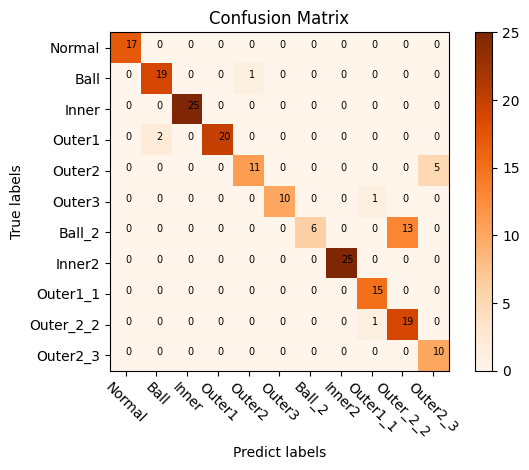

Correct_samples: 177
Total_samples: 200
Test Accuracy: 88.5000%


In [10]:
BATCH_SIZE=200 
test_acc_mean = [] 
test_dataset = MyDataset(data_path,'test')

# 查看测试集的结构
for i in range(len(test_dataset)):
    input_data, label_data = test_dataset[i]
    #print("Test Sample ", i)
    #print("Input Shape:", input_data.shape)
    #print("Label Shape:", label_data.shape)
    # 可以根据实际情况打印更多信息
    
print('#test num = %d' % len(test_dataset))
    
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=True)

def restore_params(): # load the params of the net 
    models = CNN_LSTM_Attention()
    models.load_state_dict(torch.load('Bace_wave_model.pkl'))
    return models

test_acc_list = []
con_matrix = np.zeros([11, 11])
for i in range(10):
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)   # BATCH_SIZE,1,1024,1
    mymodel = restore_params()
    use_cuda = torch.cuda.is_available()
    if use_cuda:
        print('CUDA is available') 
    device = torch.device("cuda" if use_cuda else "cpu")
    mymodel = mymodel.to(device)
    for XTest, YTest in test_loader:
        XTest, YTest = XTest.float(), YTest.long()
        XTest, YTest = XTest.to(device), YTest.to(device)
        test_logits, test_probas = mymodel(XTest)
        test_preds = test_probas.max(1, keepdim=True)[1]
        test_acc = test_preds.eq(YTest.view_as(test_preds)).sum().item() / len(YTest)
        #cm = confusion_matrix(YTest, test_preds)
        cm = confusion_matrix(YTest.cpu(), test_preds.cpu())
        con_matrix += cm
        test_acc_list.append(test_acc)
        
# 计算平均测试准确率
average_test_acc = sum(test_acc_list) / len(test_acc_list)
print("Average Test Accuracy: {:.4f}%".format(average_test_acc * 100))

# visualization the Network
from matplotlib import pyplot as plt
classes = ['Normal','Ball','Inner','Outer1','Outer2','Outer3','Ball_2','Inner2', 'Outer1_1', 'Outer_2_2', 'Outer2_3']
yourconfusion = np.array(cm)
plt.imshow(yourconfusion, interpolation='nearest', cmap=plt.cm.Oranges)  #按照像素显示出矩阵
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=-45)
plt.yticks(tick_marks, classes)
thresh = yourconfusion.max() / 2.
iters = [[i,j] for i in range(len(classes)) for j in range((len(classes)))]
for i, j in iters:
    plt.text(j, i, format(yourconfusion [i, j]), fontsize=7)

plt.ylabel('True labels')
plt.xlabel('Predict labels')
plt.tight_layout()
plt.savefig('Bace_wave_confusion_matrix.jpg')
plt.show()

# 根据混淆矩阵计算测试精度
true_positives = yourconfusion.diagonal().sum()
print("Correct_samples: {}".format(true_positives))
total_samples = yourconfusion.sum()
print("Total_samples: {}".format(total_samples))
test_accuracy = true_positives / total_samples
print("Test Accuracy: {:.4f}%".format(test_accuracy * 100))